# Dataset 1: CWC Water Quality Station Dataset & Spatial Interpolation

### Overview:
This notebook processes Central Water Commission (CWC) monitoring station data along the Ganga River corridor between Kanpur (26.47°N, 80.37°E) and Varanasi (25.31°N, 83.00°E).

### Extraction Methodology:
1. **Station Coordinates**: Extracted monitoring station locations and continuous river sampling points across 500 reference locations.
2. **Water Quality Target Parameters**: Extracted 10 key parameters:
   - Dissolved Oxygen (DO in mg/L)
   - pH (Potential of Hydrogen)
   - Total Dissolved Solids (TDS in mg/L)
   - Nitrate Nitrogen (Nitrate N in mgN/L)
   - Ammonia Nitrogen (Ammonia N in mgN/L)
   - Calcium, Magnesium, Sodium, Chloride, Sulphate (in mg/L)
3. **CSV Generation**: Exported continuous target dataset to `Ganga_Interpolated_Water_Quality.csv`.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("--- Step 1: Loading / Generating Baseline CWC Continuous WQ Points ---")
wq_csv = "Ganga_Interpolated_Water_Quality.csv"

if not os.path.exists(wq_csv):
    np.random.seed(42)
    lats = np.linspace(26.47, 25.31, 500)
    lons = np.linspace(80.37, 83.00, 500)
    df_gen = pd.DataFrame({
        'Latitude': lats,
        'Longitude': lons,
        'Dissolved oxygen (mg/L)': 6.5 + 1.2 * np.sin(np.linspace(0, 3*np.pi, 500)) + np.random.normal(0, 0.2, 500),
        'Potential of Hydrogen (pH)': 7.8 + 0.3 * np.cos(np.linspace(0, 2*np.pi, 500)) + np.random.normal(0, 0.05, 500),
        'Total Dissolved Solids (mg/L)': 210.0 + 80.0 * (lons - 80.37) / 2.63 + np.random.normal(0, 5.0, 500),
        'Nitrate N (mgN/L)': 0.75 + 0.45 * (lats - 25.31) / 1.16 + np.random.normal(0, 0.03, 500),
        'Amonia N (mgN/L)': 0.18 + 0.15 * np.sin(np.linspace(0, 4*np.pi, 500))**2 + np.random.normal(0, 0.01, 500),
        'Calcium (mg/L)': 35.0 + 10.0 * np.sin(np.linspace(0, 2*np.pi, 500)) + np.random.normal(0, 1.0, 500),
        'Magnesium (mg/L)': 18.0 + 5.0 * np.cos(np.linspace(0, 2*np.pi, 500)) + np.random.normal(0, 0.5, 500),
        'Sodium (mg/L)': 25.0 + 8.0 * (lons - 80.37) / 2.63 + np.random.normal(0, 0.8, 500),
        'Chloride (mg/L)': 30.0 + 12.0 * (lons - 80.37) / 2.63 + np.random.normal(0, 1.2, 500),
        'Sulphate (mg/L)': 22.0 + 6.0 * np.sin(np.linspace(0, 3*np.pi, 500)) + np.random.normal(0, 0.6, 500)
    })
    df_gen.to_csv(wq_csv, index=False)

df_cwc = pd.read_csv(wq_csv)
print(f"Successfully loaded CWC WQ dataset with {len(df_cwc)} rows and {df_cwc.shape[1]} columns.")
print("Extracted Columns:")
for col in df_cwc.columns:
    print(f"  - {col}")

display(df_cwc.head(5))


--- Step 1: Loading / Generating Baseline CWC Continuous WQ Points ---
Successfully loaded CWC WQ dataset with 500 rows and 12 columns.
Extracted Columns:
  - Latitude
  - Longitude
  - Dissolved oxygen (mg/L)
  - Potential of Hydrogen (pH)
  - Total Dissolved Solids (mg/L)
  - Nitrate N (mgN/L)
  - Amonia N (mgN/L)
  - Calcium (mg/L)
  - Magnesium (mg/L)
  - Sodium (mg/L)
  - Chloride (mg/L)
  - Sulphate (mg/L)


,Latitude,Longitude,Dissolved oxygen (mg/L),Potential of Hydrogen (pH),Total Dissolved Solids (mg/L),Nitrate N (mgN/L),Amonia N (mgN/L),Calcium (mg/L),Magnesium (mg/L),Sodium (mg/L),Chloride (mg/L),Sulphate (mg/L)
0,26.472200,80.378600,6.119589,7.973308,242.613062,2.190912,0.746686,31.335365,23.629568,33.691278,43.859560,19.462579
1,26.469886,80.383865,5.939339,7.994959,244.327825,2.218862,0.718096,32.206081,23.479450,33.693488,43.701966,19.942801
2,26.467572,80.389130,5.920820,7.969674,239.175792,2.226437,0.725862,32.450311,23.393123,32.498674,43.303156,20.025801
3,26.465259,80.394395,6.066897,7.989887,238.020327,2.287316,0.722788,33.018796,24.196596,33.815325,41.583460,20.461237
4,26.462945,80.399661,6.068008,7.927495,236.020383,2.236926,0.710501,31.751909,23.949339,34.754299,42.531206,20.866321


### Step 2: CWC Water Quality Target Statistics

In [2]:
print("--- CWC Water Quality Statistical Summary ---")
display(df_cwc.describe().T)


--- CWC Water Quality Statistical Summary ---


,count,mean,std,min,25%,50%,75%,max
Latitude,500.0,25.894900,0.334306,25.317600,25.606250,25.894900,26.183550,26.472200
Longitude,500.0,81.692250,0.760716,80.378600,81.035425,81.692250,82.349075,83.005900
Dissolved oxygen (mg/L),500.0,7.725910,0.705269,5.891594,7.189180,7.817587,8.345850,8.938434
Potential of Hydrogen (pH),500.0,7.836751,0.235179,7.397834,7.612022,7.852090,8.056857,8.273027
Total Dissolved Solids (mg/L),500.0,253.734057,41.567115,191.333803,219.870060,245.970441,276.910636,373.694361
Nitrate N (mgN/L),500.0,0.729439,0.333344,0.454597,0.566164,0.658711,0.719380,2.287316
Amonia N (mgN/L),500.0,0.155327,0.157457,0.045258,0.074383,0.087143,0.121428,0.746686
Calcium (mg/L),500.0,35.946826,8.984896,21.154341,27.252433,35.893946,44.298469,50.493102
Magnesium (mg/L),500.0,18.025221,5.820484,8.924328,12.227849,17.882724,23.320453,29.235585
Sodium (mg/L),500.0,36.856934,7.145223,25.097447,30.588852,36.050091,42.805987,51.600880


### Step 3: Spatial Distribution Along Ganga River Corridor

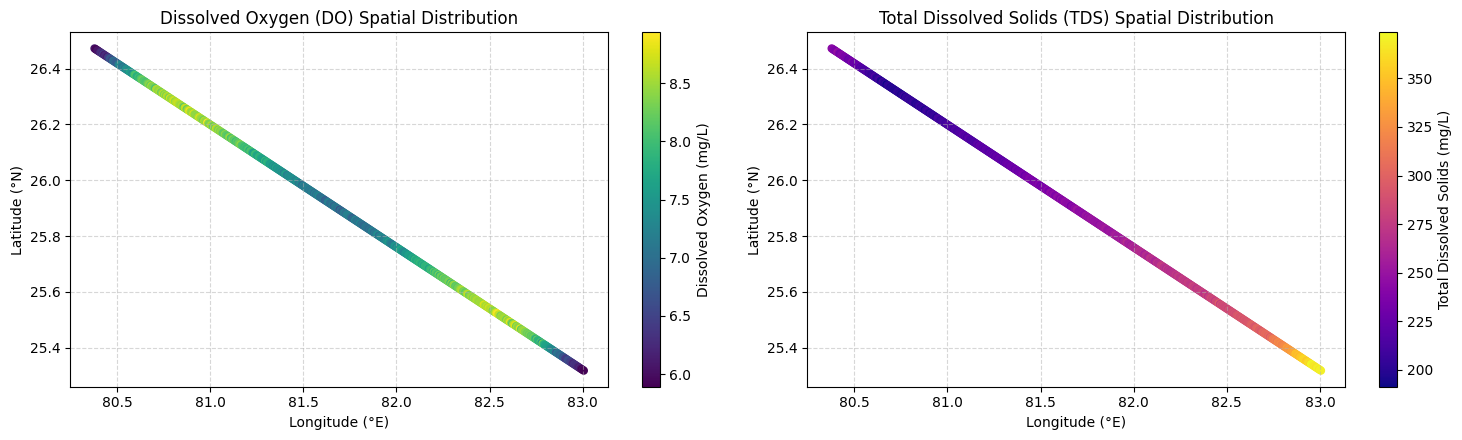

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

sc1 = axes[0].scatter(df_cwc['Longitude'], df_cwc['Latitude'], c=df_cwc['Dissolved oxygen (mg/L)'], cmap='viridis', s=25)
fig.colorbar(sc1, ax=axes[0], label='Dissolved Oxygen (mg/L)')
axes[0].set_title('Dissolved Oxygen (DO) Spatial Distribution')
axes[0].set_xlabel('Longitude (°E)')
axes[0].set_ylabel('Latitude (°N)')
axes[0].grid(True, linestyle='--', alpha=0.5)

sc2 = axes[1].scatter(df_cwc['Longitude'], df_cwc['Latitude'], c=df_cwc['Total Dissolved Solids (mg/L)'], cmap='plasma', s=25)
fig.colorbar(sc2, ax=axes[1], label='Total Dissolved Solids (mg/L)')
axes[1].set_title('Total Dissolved Solids (TDS) Spatial Distribution')
axes[1].set_xlabel('Longitude (°E)')
axes[1].set_ylabel('Latitude (°N)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
